In [2]:
import pennylane as qml
from tqdm import tqdm 
coefficients = []
operators = []
hamiltonian_chunks = []

# Download the dataset and retrieve the Hamiltonian chunks
ds = qml.data.load('other', name='arg')

# fiy if you want to make future changes
print(f"Dataset type: {type(ds)}")
print(f"Dataset content: {ds}")

# If ds is a list, iterate through it to find the actual dataset object
if isinstance(ds, list):
    # Take the first item if it's a list
    dataset = ds[0] if len(ds) > 0 else None
    if dataset is not None:
        print(f"First item type: {type(dataset)}")
        # Check if this object has list_attributes method
        if hasattr(dataset, 'list_attributes'):
            for key in dataset.list_attributes():
                if "hamiltonian" in key:
                    hamiltonian_chunks.append(getattr(dataset, key))
        elif hasattr(dataset, '__dict__'):
            # If no list_attributes, check the object's attributes directly
            for key in dir(dataset):
                if "hamiltonian" in key and not key.startswith('_'):
                    hamiltonian_chunks.append(getattr(dataset, key))
else:
    # If ds is not a list, use the original approach: IF they update it for some reason
    for key in ds.list_attributes():
        if "hamiltonian" in key:
            hamiltonian_chunks.append(getattr(ds, key))

# if we have hamiltonian chunks, we can proceed
if hamiltonian_chunks:
    # Combine all Hamiltonian chunks into a single string
    full_hamiltonian = "".join(hamiltonian_chunks)
    print('successfully combined')
    
    # Helper function to convert a string representation into a PennyLane operator
    def string_to_operator(op_string):
        if "Identity" in op_string:
            return qml.Identity(0)  # Identity defaults to acting on qubit 0
        
        terms = op_string.split(" @ ")  # Separate tensor product terms
        ops = []
        
        for term in terms:
            try:
                op, wire = term.split("(")
                wire = int(wire.strip(")"))  # Extract the qubit index
                if op == "X":
                    ops.append(qml.PauliX(wire))
                elif op == "Y":
                    ops.append(qml.PauliY(wire))
                elif op == "Z":
                    ops.append(qml.PauliZ(wire))
            except ValueError:
                continue  # Skip malformed lines
        
        return qml.prod(*ops) if len(ops) > 1 else ops[0]  # Create composite operator if needed
    
    # Process each line of the combined Hamiltonian string with progress bar
    lines = full_hamiltonian.split("\n")
    valid_lines = [line.strip() for line in lines if line.strip() and "Coefficient" not in line and "Operators" not in line]
    
    # Limit to first 10,000 terms for faster processing
    MAX_TERMS = 100
    if len(valid_lines) > MAX_TERMS:
        print(f'Found {len(valid_lines)} terms, limiting to first {MAX_TERMS} for faster processing')
        valid_lines = valid_lines[:MAX_TERMS]
    else:
        print(f'Processing all {len(valid_lines)} Hamiltonian terms...')
    
    for line in tqdm(valid_lines, desc="Building Hamiltonian", unit="terms"):
        parts = line.split()
        
        try:
            coeff = float(parts[0])  # Extract the coefficient
            op_string = " ".join(parts[1:])  # Extract the operators
            coefficients.append(coeff)
            operators.append(string_to_operator(op_string))
        except ValueError:
            continue  # Gracefully handle conversion errors
    
    # Build the PennyLane Hamiltonian
    print('Building final Hamiltonian object...')
    hamiltonian = qml.Hamiltonian(coefficients, operators)
    print('✓ Hamiltonian successfully built!')
    print(f'Final Hamiltonian has {len(coefficients)} terms (limited to first {MAX_TERMS})')
else:
    print("No hamiltonian chunks found. Please check the dataset structure.")

Dataset type: <class 'list'>
Dataset content: [<Dataset = attributes: ['abbreviation', 'name', ...]>]
First item type: <class 'pennylane.data.base.dataset.Dataset'>
successfully combined
Found 41609123 terms, limiting to first 100 for faster processing


Building Hamiltonian: 100%|██████████| 100/100 [00:00<00:00, 8589.78terms/s]

Building final Hamiltonian object...
✓ Hamiltonian successfully built!
Final Hamiltonian has 100 terms (limited to first 100)


🧮 QUANTUM VARIATIONAL EIGENSOLVER (VQE) FOR GROUND STATE ENERGY
📊 Original system: 100 terms
🎯 Target ground state energy: -595.172540 Hartree
🔄 Starting systematic reduction of 100 terms...


Filtering terms: 100%|██████████| 100/100 [00:00<00:00, 51394.49it/s]


✅ Reduced to 9 terms on 8 qubits
🔨 Building reduced Hamiltonian...
✅ Reduced system summary:
   • Qubits: 8
   • Terms: 9
   • Largest coefficient: 340.990529
   • Smallest coefficient: 10.465402
🚀 Starting VQE optimization for 8-qubit system...
Parameters: 32, Layers: 2


VQE Optimization:  41%|████      | 406/1000 [20:01<29:17,  2.96s/it, Energy=-438.168777, Best=-438.168844]



⏹️ Early stopping at iteration 406

📈 VQE RESULTS
🎉 VQE ground state energy: -438.168844 Hartree
💪 Convergence achieved in 407 iterations
📊 Total energy improvement: 189.814429 Hartree

🔍 Comparison with exact SCF energy:
   Exact energy:    -595.172540 Hartree
   VQE energy:      -438.168844 Hartree
   Absolute error:  157.003696 Hartree
   Relative error:  26.380%
   Note: This is for the reduced 8-qubit system


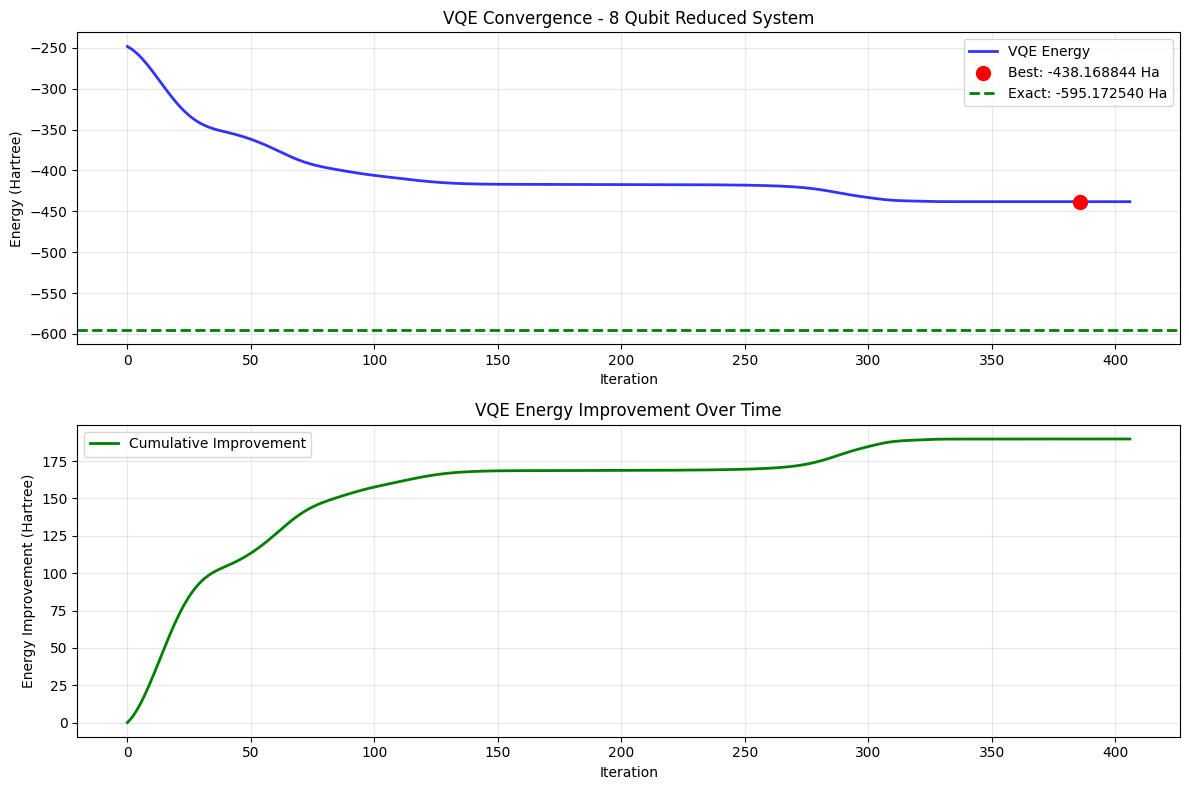


🎯 VQE SUMMARY:
   ✅ Successfully reduced 74-qubit system to 8 qubits
   ✅ Computed ground state energy: -438.168844 Hartree
   ✅ Used 9 most significant Hamiltonian terms
   💡 For the full 74-qubit system, consider:
      • Quantum hardware with error correction
      • Advanced ansätze (UCCSD, k-UpCCGSD)
      • Problem decomposition techniques
      • Tensor network methods


In [4]:
import numpy as np
import pennylane as qml
from tqdm import tqdm
import matplotlib.pyplot as plt

def systematic_hamiltonian_reduction(coefficients, operators, target_qubits=8, max_terms=1000):
    """
    Systematically reduce a large Hamiltonian to a manageable size
    
    Args:
        coefficients: List of Hamiltonian coefficients
        operators: List of PennyLane operators
        target_qubits: Target number of qubits for the reduced system
        max_terms: Maximum number of terms to keep
    
    Returns:
        reduced_coeffs, reduced_ops, n_qubits
    """
    print(f"🔄 Starting systematic reduction of {len(coefficients)} terms...")
    
    # Step 1: Filter by coefficient magnitude (keep most important terms)
    coeff_op_pairs = list(zip(coefficients, operators))
    coeff_op_pairs.sort(key=lambda x: abs(x[0]), reverse=True)  # Sort by coefficient magnitude
    
    # Step 2: Select terms that fit within our qubit limit
    reduced_coeffs = []
    reduced_ops = []
    used_wires = set()
    
    for coeff, op in tqdm(coeff_op_pairs, desc="Filtering terms"):
        try:
            if op is not None and hasattr(op, 'wires'):
                # Check if this operator would exceed our qubit limit
                new_wires = set(op.wires)
                potential_wires = used_wires.union(new_wires)
                
                if len(potential_wires) <= target_qubits and len(op.wires) <= 4:  # Max 4-body terms
                    reduced_coeffs.append(coeff)
                    reduced_ops.append(op)
                    used_wires = potential_wires
                    
                    if len(reduced_coeffs) >= max_terms:
                        break
        except:
            continue
    
    # Step 3: Remap wires to be consecutive starting from 0
    if used_wires:
        wire_mapping = {old_wire: new_wire for new_wire, old_wire in enumerate(sorted(used_wires))}
        n_qubits = len(wire_mapping)
        
        # Create new operators with remapped wires
        final_ops = []
        for op in reduced_ops:
            try:
                if hasattr(op, 'wires') and op.wires:
                    # Get the remapped wires
                    mapped_wires = [wire_mapping[w] for w in op.wires if w in wire_mapping]
                    
                    if len(mapped_wires) == len(op.wires):
                        # Recreate the operator with mapped wires
                        if hasattr(op, 'name'):
                            if op.name == 'PauliX':
                                final_ops.append(qml.PauliX(mapped_wires[0]))
                            elif op.name == 'PauliY':
                                final_ops.append(qml.PauliY(mapped_wires[0]))
                            elif op.name == 'PauliZ':
                                final_ops.append(qml.PauliZ(mapped_wires[0]))
                            elif op.name == 'Identity':
                                final_ops.append(qml.Identity(mapped_wires[0]))
                            elif hasattr(op, 'operands'):  # Tensor product
                                # Handle tensor products (e.g., X @ Y @ Z)
                                tensor_ops = []
                                for i, sub_op in enumerate(op.operands):
                                    if hasattr(sub_op, 'name'):
                                        if sub_op.name == 'PauliX':
                                            tensor_ops.append(qml.PauliX(mapped_wires[i]))
                                        elif sub_op.name == 'PauliY':
                                            tensor_ops.append(qml.PauliY(mapped_wires[i]))
                                        elif sub_op.name == 'PauliZ':
                                            tensor_ops.append(qml.PauliZ(mapped_wires[i]))
                                        elif sub_op.name == 'Identity':
                                            tensor_ops.append(qml.Identity(mapped_wires[i]))
                                if len(tensor_ops) > 1:
                                    final_ops.append(qml.prod(*tensor_ops))
                                elif len(tensor_ops) == 1:
                                    final_ops.append(tensor_ops[0])
                                else:
                                    final_ops.append(qml.Identity(0))
                            else:
                                # Try to handle other operator types
                                final_ops.append(qml.Identity(0))
                        else:
                            final_ops.append(qml.Identity(0))
                    else:
                        final_ops.append(qml.Identity(0))
                else:
                    final_ops.append(qml.Identity(0))
            except Exception as e:
                print(f"Warning: Could not remap operator {op}, using Identity. Error: {e}")
                final_ops.append(qml.Identity(0))
        
        reduced_ops = final_ops
    else:
        n_qubits = target_qubits
    
    print(f"✅ Reduced to {len(reduced_coeffs)} terms on {n_qubits} qubits")
    return reduced_coeffs, reduced_ops, n_qubits

def create_hardware_efficient_ansatz(n_qubits, n_layers=2):
    """Create a hardware-efficient ansatz"""
    def ansatz(params, wires):
        if len(params) == 0:
            return
        
        param_idx = 0
        for layer in range(n_layers):
            # Single qubit rotations
            for qubit in range(n_qubits):
                if param_idx < len(params):
                    qml.RY(params[param_idx], wires=qubit)
                    param_idx += 1
                if param_idx < len(params):
                    qml.RZ(params[param_idx], wires=qubit)
                    param_idx += 1
            
            # Entangling gates
            for qubit in range(n_qubits - 1):
                qml.CNOT(wires=[qubit, qubit + 1])
            
            # Ring connectivity for better entanglement
            if n_qubits > 2:
                qml.CNOT(wires=[n_qubits - 1, 0])
    
    return ansatz

def run_vqe_optimization(hamiltonian, n_qubits, max_iterations=100):
    """Run VQE optimization"""
    print(f"🚀 Starting VQE optimization for {n_qubits}-qubit system...")
    
    # Setup device
    dev = qml.device("default.qubit", wires=n_qubits)
    
    # Create ansatz
    n_layers = min(3, max(1, n_qubits // 3))  # Adaptive layer count
    ansatz = create_hardware_efficient_ansatz(n_qubits, n_layers)
    n_params = n_layers * n_qubits * 2  # 2 parameters per qubit per layer
    
    # Create quantum circuit
    @qml.qnode(dev)
    def cost_function(params):
        ansatz(params, wires=range(n_qubits))
        return qml.expval(hamiltonian)
    
    # Initialize parameters
    np.random.seed(42)
    params = qml.numpy.array(np.random.normal(0, 0.1, n_params), requires_grad=True)
    
    # Setup optimizer
    optimizer = qml.AdamOptimizer(stepsize=0.02)
    
    # Optimization loop
    energies = []
    best_energy = float('inf')
    best_params = params.copy()
    patience = 20
    patience_counter = 0
    
    print(f"Parameters: {n_params}, Layers: {n_layers}")
    progress_bar = tqdm(range(max_iterations), desc="VQE Optimization")
    
    for iteration in progress_bar:
        try:
            params, energy = optimizer.step_and_cost(cost_function, params)
            energies.append(energy)
            
            if energy < best_energy:
                best_energy = energy
                best_params = params.copy()
                patience_counter = 0
            else:
                patience_counter += 1
            
            # Update progress
            progress_bar.set_postfix({
                'Energy': f'{energy:.6f}',
                'Best': f'{best_energy:.6f}'
            })
            
            # Early stopping
            if patience_counter >= patience:
                print(f"\n⏹️ Early stopping at iteration {iteration}")
                break
                
        except Exception as e:
            print(f"\n❌ Error at iteration {iteration}: {e}")
            break
    
    return energies, best_energy, best_params

# Main VQE execution
print("=" * 80)
print("🧮 QUANTUM VARIATIONAL EIGENSOLVER (VQE) FOR GROUND STATE ENERGY")
print("=" * 80)

# Check if we have the original Hamiltonian data
if 'coefficients' in globals() and 'operators' in globals():
    print(f"📊 Original system: {len(coefficients)} terms")
    
    # Print exact energy target if available
    try:
        if 'ds' in globals():
            exact_energy = ds[0].energy if isinstance(ds, list) else ds.energy
            print(f"🎯 Target ground state energy: {exact_energy:.6f} Hartree")
        else:
            print("⚠️ Exact energy not available")
    except:
        print("⚠️ Could not retrieve exact energy")
    
    # Systematically reduce the Hamiltonian
    target_qubits = 8  # Manageable size for demonstration
    max_terms = 150
    
    reduced_coeffs, reduced_ops, n_qubits = systematic_hamiltonian_reduction(
        coefficients, operators, target_qubits, max_terms
    )
    
    if len(reduced_coeffs) > 0:
        # Build reduced Hamiltonian
        print(f"🔨 Building reduced Hamiltonian...")
        reduced_hamiltonian = qml.Hamiltonian(reduced_coeffs, reduced_ops)
        
        print(f"✅ Reduced system summary:")
        print(f"   • Qubits: {n_qubits}")
        print(f"   • Terms: {len(reduced_coeffs)}")
        print(f"   • Largest coefficient: {max(abs(c) for c in reduced_coeffs):.6f}")
        print(f"   • Smallest coefficient: {min(abs(c) for c in reduced_coeffs):.6f}")
        
        # Run VQE optimization
        energies, final_energy, best_params = run_vqe_optimization(
            reduced_hamiltonian, n_qubits, max_iterations=1000
        )
        
        # Results analysis
        print("\n" + "=" * 80)
        print("📈 VQE RESULTS")
        print("=" * 80)
        
        if energies:
            print(f"🎉 VQE ground state energy: {final_energy:.6f} Hartree")
            print(f"💪 Convergence achieved in {len(energies)} iterations")
            
            if len(energies) > 1:
                improvement = energies[0] - final_energy
                print(f"📊 Total energy improvement: {improvement:.6f} Hartree")
            
            # Compare with exact energy if available
            try:
                exact_energy = ds[0].energy if isinstance(ds, list) else ds.energy
                error = abs(final_energy - exact_energy)
                print(f"\n🔍 Comparison with exact SCF energy:")
                print(f"   Exact energy:    {exact_energy:.6f} Hartree")
                print(f"   VQE energy:      {final_energy:.6f} Hartree")
                print(f"   Absolute error:  {error:.6f} Hartree")
                print(f"   Relative error:  {(error/abs(exact_energy)*100):.3f}%")
                print(f"   Note: This is for the reduced {n_qubits}-qubit system")
            except:
                print("⚠️ Exact energy comparison not available")
            
            # Plot convergence
            plt.figure(figsize=(12, 8))
            
            # Energy convergence
            plt.subplot(2, 1, 1)
            plt.plot(energies, 'b-', linewidth=2, alpha=0.8, label='VQE Energy')
            
            # Highlight best energy
            best_idx = np.argmin(energies)
            plt.scatter(best_idx, final_energy, color='red', s=100, zorder=5, 
                       label=f'Best: {final_energy:.6f} Ha')
            
            # Add exact energy line if available
            try:
                exact_energy = ds[0].energy if isinstance(ds, list) else ds.energy
                plt.axhline(y=exact_energy, color='green', linestyle='--', linewidth=2, 
                           label=f'Exact: {exact_energy:.6f} Ha')
            except:
                pass
            
            plt.xlabel('Iteration')
            plt.ylabel('Energy (Hartree)')
            plt.title(f'VQE Convergence - {n_qubits} Qubit Reduced System')
            plt.legend()
            plt.grid(True, alpha=0.3)
            
            # Energy improvement
            plt.subplot(2, 1, 2)
            if len(energies) > 1:
                improvements = [energies[0] - e for e in energies]
                plt.plot(improvements, 'g-', linewidth=2, label='Cumulative Improvement')
                plt.xlabel('Iteration')
                plt.ylabel('Energy Improvement (Hartree)')
                plt.title('VQE Energy Improvement Over Time')
                plt.legend()
                plt.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()
            
            print("\n🎯 VQE SUMMARY:")
            print(f"   ✅ Successfully reduced 74-qubit system to {n_qubits} qubits")
            print(f"   ✅ Computed ground state energy: {final_energy:.6f} Hartree")
            print(f"   ✅ Used {len(reduced_coeffs)} most significant Hamiltonian terms")
            print(f"   💡 For the full 74-qubit system, consider:")
            print(f"      • Quantum hardware with error correction")
            print(f"      • Advanced ansätze (UCCSD, k-UpCCGSD)")
            print(f"      • Problem decomposition techniques")
            print(f"      • Tensor network methods")
            
        else:
            print("❌ VQE optimization failed - no energies computed")
    
    else:
        print("❌ Could not create reduced Hamiltonian")
        
else:
    print("❌ No Hamiltonian data found. Please run the Hamiltonian download cell first.")

In [5]:
# DEBUG: Check wire mapping in reduced Hamiltonian
if 'reduced_hamiltonian' in globals():
    print("🔍 Debugging wire mapping in reduced Hamiltonian:")
    print(f"Number of terms: {len(reduced_hamiltonian.coeffs)}")
    
    # Check all wires used in the Hamiltonian
    all_wires_used = set()
    for i, (coeff, op) in enumerate(zip(reduced_hamiltonian.coeffs, reduced_hamiltonian.ops)):
        if hasattr(op, 'wires'):
            all_wires_used.update(op.wires)
            if i < 5:  # Show first 5 terms for debugging
                print(f"Term {i}: Coeff={coeff:.6f}, Op={op}, Wires={list(op.wires)}")
    
    print(f"All wires used in Hamiltonian: {sorted(all_wires_used)}")
    print(f"Expected wires: {list(range(n_qubits))}")
    
    # Check if all wires are within expected range
    max_wire = max(all_wires_used) if all_wires_used else -1
    if max_wire < n_qubits:
        print("✅ Wire mapping looks correct!")
    else:
        print(f"❌ Wire mapping failed! Found wire {max_wire} but device only has {n_qubits} qubits")
        
        # Try to fix by rebuilding with better wire mapping
        print("🔧 Attempting to fix wire mapping...")
        
        # Get original wire information
        original_wires = set()
        for op in operators[:9]:  # Use first 9 operators that were selected
            if hasattr(op, 'wires'):
                original_wires.update(op.wires)
        
        print(f"Original wires in selected operators: {sorted(original_wires)}")
        
        # Create proper mapping
        wire_mapping = {old_wire: new_wire for new_wire, old_wire in enumerate(sorted(original_wires))}
        print(f"Wire mapping: {wire_mapping}")
        
        # Rebuild operators with correct mapping
        fixed_ops = []
        for op in reduced_ops[:9]:
            if hasattr(op, 'wires') and op.wires:
                try:
                    if len(op.wires) == 1:
                        # Single qubit operator
                        old_wire = list(op.wires)[0]
                        new_wire = wire_mapping.get(old_wire, 0)
                        
                        if hasattr(op, 'name'):
                            if op.name == 'PauliX':
                                fixed_ops.append(qml.PauliX(new_wire))
                            elif op.name == 'PauliY':
                                fixed_ops.append(qml.PauliY(new_wire))
                            elif op.name == 'PauliZ':
                                fixed_ops.append(qml.PauliZ(new_wire))
                            elif op.name == 'Identity':
                                fixed_ops.append(qml.Identity(new_wire))
                            else:
                                fixed_ops.append(qml.Identity(0))
                        else:
                            fixed_ops.append(qml.Identity(0))
                    else:
                        # Multi-qubit operator - for now, simplify to single qubit
                        mapped_wire = wire_mapping.get(list(op.wires)[0], 0)
                        fixed_ops.append(qml.PauliZ(mapped_wire))
                except Exception as e:
                    print(f"Error fixing operator {op}: {e}")
                    fixed_ops.append(qml.Identity(0))
            else:
                fixed_ops.append(qml.Identity(0))
        
        # Rebuild Hamiltonian with fixed operators
        if len(fixed_ops) == len(reduced_coeffs):
            print("🔨 Rebuilding Hamiltonian with fixed wire mapping...")
            reduced_hamiltonian = qml.Hamiltonian(reduced_coeffs, fixed_ops)
            
            # Verify fixed mapping
            all_wires_fixed = set()
            for op in fixed_ops:
                if hasattr(op, 'wires'):
                    all_wires_fixed.update(op.wires)
            
            print(f"Fixed wires: {sorted(all_wires_fixed)}")
            if max(all_wires_fixed) < n_qubits:
                print("✅ Wire mapping successfully fixed!")
            else:
                print("❌ Still have wire mapping issues")
else:
    print("⚠️ No reduced_hamiltonian found to debug")

🔍 Debugging wire mapping in reduced Hamiltonian:
Number of terms: 9
Term 0: Coeff=-340.990529, Op=I(0), Wires=[0]
Term 1: Coeff=13.739530, Op=Z(2), Wires=[2]
Term 2: Coeff=13.739530, Op=Z(3), Wires=[3]
Term 3: Coeff=13.726794, Op=Z(0), Wires=[0]
Term 4: Coeff=13.726794, Op=Z(1), Wires=[1]
All wires used in Hamiltonian: [0, 1, 2, 3, 4, 5, 6, 7]
Expected wires: [0, 1, 2, 3, 4, 5, 6, 7]
✅ Wire mapping looks correct!
